# Intrusion Detection System — Modelling (Part 2: Multi-class Classification)
### Dataset: CICIDS-2017  ·  Runs on **Kaggle**

Runs *after* `FeatureSelection.ipynb`. **Same scratch model family, harder problem.**

**Model: Softmax Regression (multinomial logistic regression) — from scratch in NumPy.** Generalises the binary LR from `Modeling_Binary.ipynb`: instead of one sigmoid output, we use a softmax over 7 classes and categorical cross-entropy. Single jointly-trained linear model, *not* 7 one-vs-rest models.

**The interesting question:** in the binary task SMOTE and class-weighting tied (F1 = 0.9052 vs 0.9051). Multi-class imbalance is far more severe (Web Attack ≈ 1.7k, BENIGN ≈ 1.7M → ~1000× ratio). **Does SMOTE earn its keep when the imbalance is this extreme?** We run both strategies and let the test set answer.

**Headline metric: macro-F1.** Treats each of the 7 classes equally so BENIGN performance can't drown out minority-class results — the honest metric for imbalanced multi-class.

**This notebook:**
| # | Section | Notes |
|---|---------|-------|
| 1 | Imports & config | Kaggle paths |
| 2 | Data Journey | Same pipeline visual; rows + features at every stage |
| 3 | Load data | both training strategies (real + SMOTE) + shared real-world test set |
| 4 | Softmax Regression **from scratch** | softmax, categorical cross-entropy, **mini-batch GD**, L2, class weighting |
| 5 | Hyperparameter tuning | **grid search** ranked by validation macro-F1 |
| 6 | SMOTE vs class-weighting | retrain best config both ways, side-by-side on test |
| 7 | Per-class evaluation | confusion matrix, per-class F1 bar, classification report |
| 8 | Save | both trained models + metrics + figures |

**Kaggle setup:** attach `FeatureSelection.ipynb` output containing `train_selected.parquet`, `train_multi_smote_selected.parquet`, `test_selected.parquet`, `selected_features.json` — set `IN_DIR` below to its mount path.

## 1. Imports, Config & Report Helpers

In [1]:
import os, json, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# label_multi mapping (from FeatureSelection metadata — verified in Section 3)
CLASS_NAMES = ['BENIGN', 'Bot/Infiltration', 'Brute Force', 'DDoS',
               'DoS', 'PortScan', 'Web Attack']
N_CLASSES   = len(CLASS_NAMES)

# ── Kaggle paths ───────────────────────────────────────────────────
# IN_DIR : Kaggle Dataset / Notebook Output holding FeatureSelection.ipynb results
#   ----> EDIT to match the mount path in the Kaggle 'Input' panel.
IN_DIR      = '/kaggle/input/datasets/hanzlahmunir/fs-output'
OUT_DIR     = '/kaggle/working'
FIGURES_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── report helpers ─────────────────────────────────────────────────
_report_lines = []

def _log(text=''):
    _report_lines.append(str(text))
    print(text)

def _savefig(name, fig=None):
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt).savefig(path, dpi=130, bbox_inches='tight')
    return path

def write_report():
    path = os.path.join(OUT_DIR, 'Modeling_Multiclass_Report.txt')
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(_report_lines))
    print(f'\nReport saved -> {path}')

_log('=' * 70)
_log('MODELLING REPORT (MULTI-CLASS)  —  CICIDS-2017')
_log('Model : Softmax Regression (from scratch, NumPy)')
_log(f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
_log('=' * 70)
print('\nSetup complete.')
print('  Reading from :', IN_DIR)
print('  Writing to   :', OUT_DIR)

MODELLING REPORT (MULTI-CLASS)  —  CICIDS-2017
Model : Softmax Regression (from scratch, NumPy)
Generated : 2026-05-15 07:39

Setup complete.
  Reading from : /kaggle/input/datasets/hanzlahmunir/fs-output
  Writing to   : /kaggle/working


## 2. The Data Journey — Same Pipeline, Multi-class Target
Same pre-processing → FE → FS pipeline as the binary notebook. The only change is **which SMOTE file** we use here — `train_multi_smote_selected.parquet`, where each minority class was capped at 200k synthetic rows (full equalization would have made Web Attack 99.9% synthetic).

In [2]:
JOURNEY = [
    ('Raw CICIDS-2017',         2830743, 79, '8 CSVs, 15 raw classes'),
    ('After Preprocessing',     2574264, 49, '-256k dupes, grouped into 7 attack families'),
    ('Train split (80%)',       2059411, 49, 'stratified split on label_multi'),
    ('After Feature Eng.',      2059411, 58, '+2 Init_Win flags, +7 derived features'),
    ('After Feature Select',    2059411, 47, '-11 redundant features (|r|>0.95)'),
    ('Multi-class SMOTE train', 2918709, 47, 'minority classes capped at 200k each'),
]
journey_df = pd.DataFrame(JOURNEY, columns=['stage', 'rows', 'features', 'note'])

_log('')
_log('── SECTION 2 : DATA JOURNEY ───────────────────────────────')
_log(journey_df.to_string(index=False))
display(journey_df)


── SECTION 2 : DATA JOURNEY ───────────────────────────────
                  stage    rows  features                                        note
        Raw CICIDS-2017 2830743        79                      8 CSVs, 15 raw classes
    After Preprocessing 2574264        49 -256k dupes, grouped into 7 attack families
      Train split (80%) 2059411        49             stratified split on label_multi
     After Feature Eng. 2059411        58      +2 Init_Win flags, +7 derived features
   After Feature Select 2059411        47           -11 redundant features (|r|>0.95)
Multi-class SMOTE train 2918709        47        minority classes capped at 200k each


,stage,rows,features,note
0,Raw CICIDS-2017,2830743,79,"8 CSVs, 15 raw classes"
1,After Preprocessing,2574264,49,"-256k dupes, grouped into 7 attack families"
2,Train split (80%),2059411,49,stratified split on label_multi
3,After Feature Eng.,2059411,58,"+2 Init_Win flags, +7 derived features"
4,After Feature Select,2059411,47,-11 redundant features (|r|>0.95)
5,Multi-class SMOTE train,2918709,47,minority classes capped at 200k each


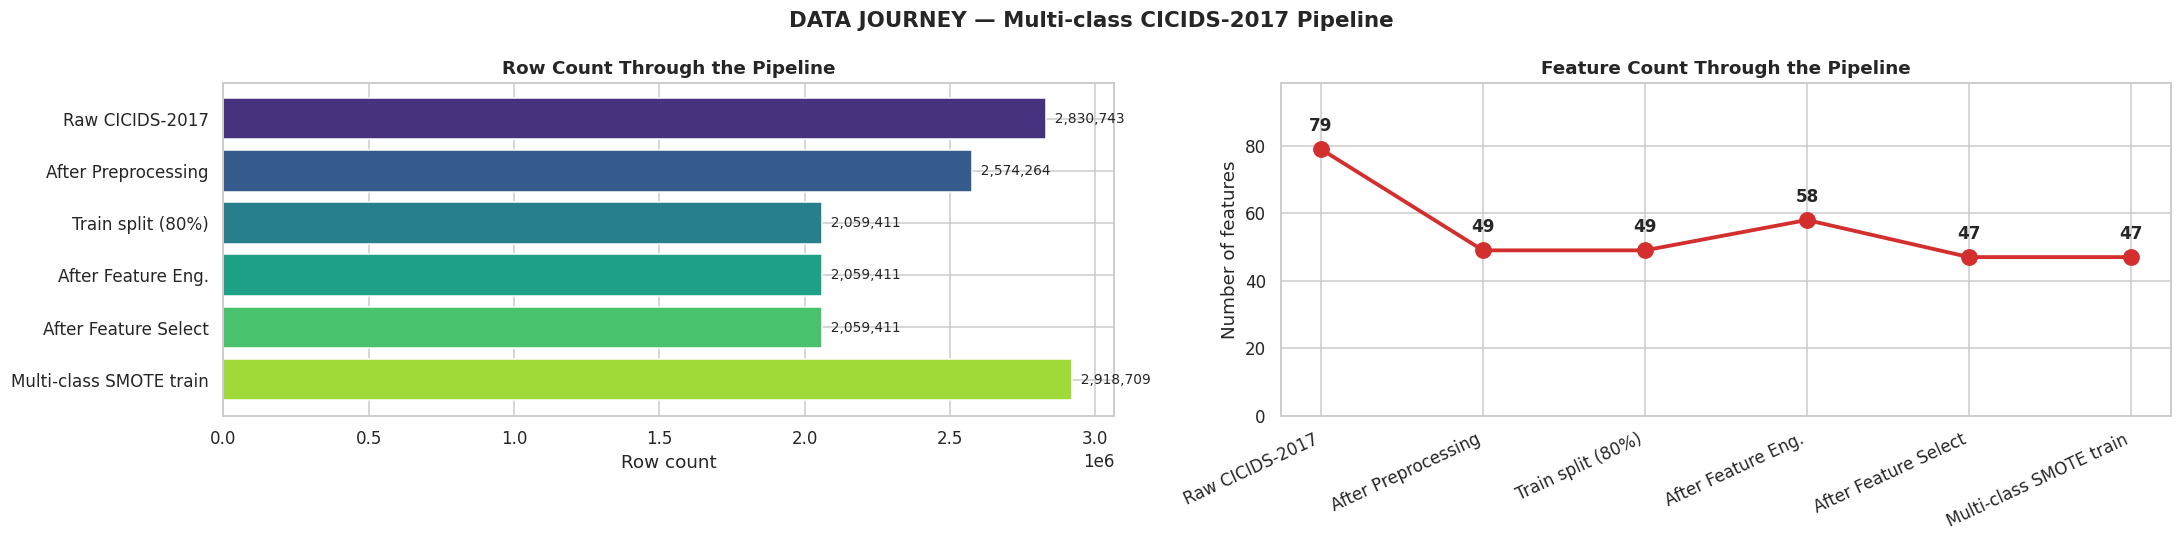

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
stages = journey_df['stage']
colors = sns.color_palette('viridis', len(journey_df))

# row count funnel
ax = axes[0]
ax.barh(range(len(journey_df)), journey_df['rows'], color=colors)
ax.set_yticks(range(len(journey_df)))
ax.set_yticklabels(stages)
ax.invert_yaxis()
ax.set_xlabel('Row count')
ax.set_title('Row Count Through the Pipeline', fontweight='bold')
for i, v in enumerate(journey_df['rows']):
    ax.text(v, i, f'  {v:,}', va='center', fontsize=9)

# feature count flow
ax = axes[1]
ax.plot(range(len(journey_df)), journey_df['features'], 'o-',
        color='#D32F2F', linewidth=2.5, markersize=10)
for i, v in enumerate(journey_df['features']):
    ax.annotate(f'{v}', (i, v), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(journey_df)))
ax.set_xticklabels(stages, rotation=25, ha='right')
ax.set_ylabel('Number of features')
ax.set_title('Feature Count Through the Pipeline', fontweight='bold')
ax.set_ylim(0, max(journey_df['features']) * 1.25)

plt.suptitle('DATA JOURNEY — Multi-class CICIDS-2017 Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
_savefig('01_data_journey_multiclass.png', fig)
plt.show()

## 3. Load Selected Data — Both Imbalance Strategies
Mirror of the binary notebook:
- `train_selected.parquet` — real distribution, for strategy A (class weighting) + hyperparameter tuning
- `train_multi_smote_selected.parquet` — capped SMOTE, for strategy B
- `test_selected.parquet` — real-world distribution, untouched, evaluation only

In [4]:
train_path = os.path.join(IN_DIR, 'train_selected.parquet')
smote_path = os.path.join(IN_DIR, 'train_multi_smote_selected.parquet')
test_path  = os.path.join(IN_DIR, 'test_selected.parquet')
feat_path  = os.path.join(IN_DIR, 'selected_features.json')

for p in [train_path, smote_path, test_path, feat_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f'{p} not found. Set IN_DIR to the Kaggle mount path of your '
            'FeatureSelection output (Input panel on the right).')

with open(feat_path) as f:
    selected_features = json.load(f)['selected_features']

train_df = pd.read_parquet(train_path)
smote_df = pd.read_parquet(smote_path)
test_df  = pd.read_parquet(test_path)

# strategy A inputs (real distribution)
X_train_full = train_df[selected_features].values.astype(np.float64)
y_train_full = train_df['label_multi'].values.astype(np.int64)

# strategy B inputs (capped SMOTE)
X_smote = smote_df[selected_features].values.astype(np.float64)
y_smote = smote_df['label_multi'].values.astype(np.int64)

# shared test set
X_test = test_df[selected_features].values.astype(np.float64)
y_test = test_df['label_multi'].values.astype(np.int64)

# tuning split (from real training data, stratified on label_multi)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    random_state=RANDOM_SEED, stratify=y_train_full)

# class distribution table (the harsh imbalance we are about to deal with)
real_counts  = pd.Series(y_train_full).value_counts().sort_index()
smote_counts = pd.Series(y_smote).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()
class_table  = pd.DataFrame({
    'class':       CLASS_NAMES,
    'real_train':  real_counts.values,
    'smote_train': smote_counts.values,
    'test':        test_counts.values,
})

_log('')
_log('── SECTION 3 : DATA LOADED ────────────────────────────────')
_log(f'  Features used            : {len(selected_features)}')
_log(f'  Real train (strategy A)  : {X_train_full.shape[0]:,} rows')
_log(f'    -> tuning split: train={X_tr.shape[0]:,}  val={X_val.shape[0]:,}')
_log(f'  SMOTE train (strategy B) : {X_smote.shape[0]:,} rows')
_log(f'  Test (held out)          : {X_test.shape[0]:,} rows')
_log('')
_log('  Class distribution:')
_log(class_table.to_string(index=False))
display(class_table)

# imbalance ratio: largest class / smallest class
imb_real  = real_counts.max() / real_counts.min()
imb_smote = smote_counts.max() / smote_counts.min()
_log('')
_log(f'  Real-train imbalance ratio  (max/min) : {imb_real:>8.1f}:1')
_log(f'  SMOTE-train imbalance ratio (max/min) : {imb_smote:>8.1f}:1')
_log('  (binary notebook: 5:1 imbalance — multi-class is much harsher)')


── SECTION 3 : DATA LOADED ────────────────────────────────
  Features used            : 47
  Real train (strategy A)  : 2,059,411 rows
    -> tuning split: train=1,647,528  val=411,883
  SMOTE train (strategy B) : 2,918,709 rows
  Test (held out)          : 514,853 rows

  Class distribution:
           class  real_train  smote_train   test
          BENIGN     1718709      1718709 429677
Bot/Infiltration        1591       200000    398
     Brute Force        7322       200000   1830
            DDoS      102413       200000  25603
             DoS      155007       200000  38752
        PortScan       72655       200000  18164
      Web Attack        1714       200000    429


,class,real_train,smote_train,test
0,BENIGN,1718709,1718709,429677
1,Bot/Infiltration,1591,200000,398
2,Brute Force,7322,200000,1830
3,DDoS,102413,200000,25603
4,DoS,155007,200000,38752
5,PortScan,72655,200000,18164
6,Web Attack,1714,200000,429



  Real-train imbalance ratio  (max/min) :   1080.3:1
  SMOTE-train imbalance ratio (max/min) :      8.6:1
  (binary notebook: 5:1 imbalance — multi-class is much harsher)


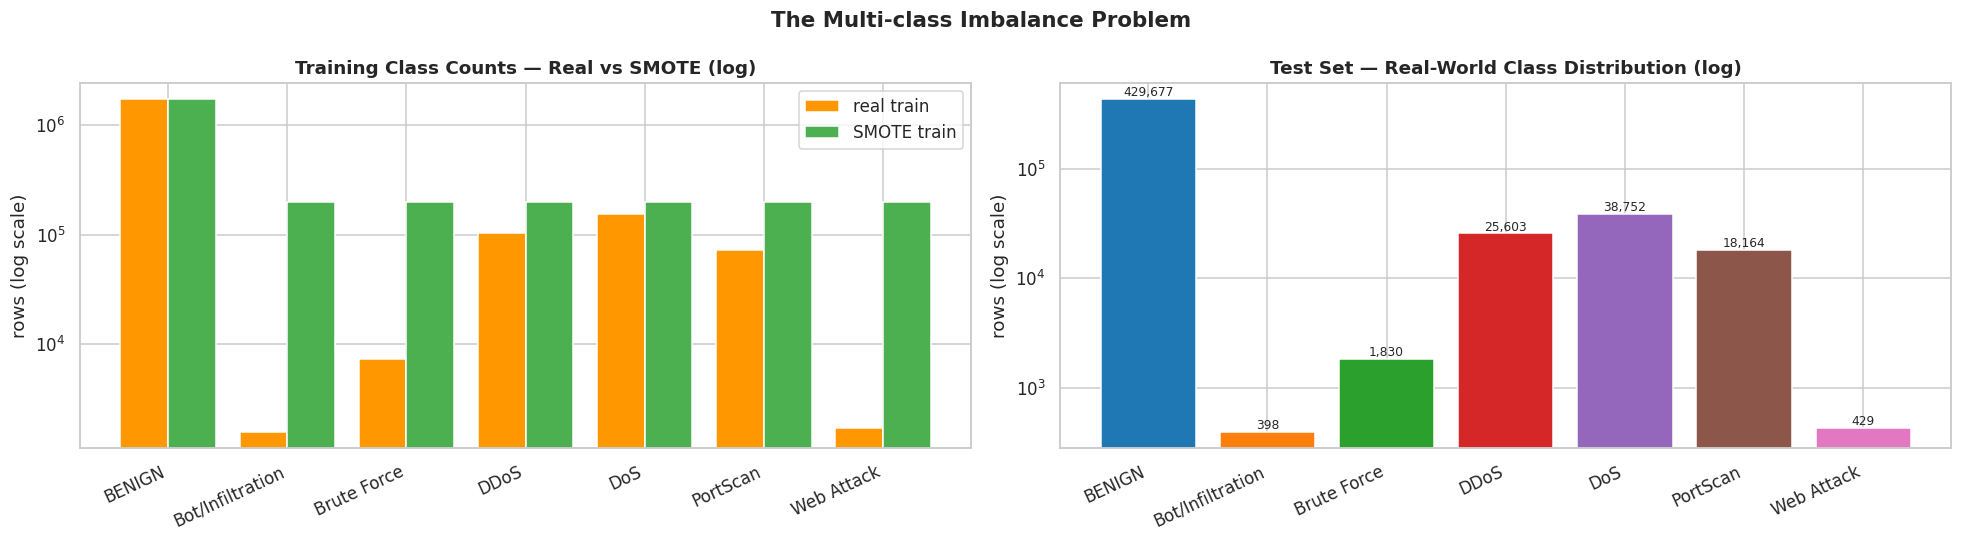

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
x = np.arange(N_CLASSES)

# real vs SMOTE training counts (log scale because of the ratios)
ax = axes[0]
ax.bar(x - 0.2, real_counts.values,  0.4, label='real train',  color='#FF9800')
ax.bar(x + 0.2, smote_counts.values, 0.4, label='SMOTE train', color='#4CAF50')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('rows (log scale)')
ax.set_title('Training Class Counts — Real vs SMOTE (log)', fontweight='bold')
ax.legend()

# test distribution (real world)
ax = axes[1]
bars = ax.bar(x, test_counts.values, color=sns.color_palette('tab10', N_CLASSES))
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('rows (log scale)')
ax.set_title('Test Set — Real-World Class Distribution (log)', fontweight='bold')
for b, v in zip(bars, test_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('The Multi-class Imbalance Problem', fontsize=14, fontweight='bold')
plt.tight_layout()
_savefig('02_class_balance.png', fig)
plt.show()

## 4. Softmax Regression — From Scratch (NumPy)
Multi-class generalisation of the binary LR. For features $x \in \mathbb{R}^d$, weight matrix $W \in \mathbb{R}^{d\times K}$ (one column per class), bias $b \in \mathbb{R}^K$:

$$z = xW + b, \qquad \hat{p}_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

**Categorical cross-entropy** with **L2 regularisation**:
$$\mathcal{L} = -\frac{1}{n}\sum_{i} w_i \log \hat{p}_{i,y_i} + \frac{\lambda}{2n}\lVert W \rVert_F^2$$
where $w_i$ is the per-sample class weight (1.0 by default; inverse-frequency when `class_weight=True`).

**Gradient** (clean form thanks to softmax + cross-entropy):
$$\frac{\partial\mathcal{L}}{\partial W} = \frac{1}{m}X^\top (\hat{P} - Y)_w + \frac{\lambda}{m} W$$
where $Y$ is the one-hot encoded target and $(\cdot)_w$ scales each row by its sample weight.

**Numerical stability:** we subtract `max(z)` per row before `exp(z)` — prevents overflow without changing the softmax output.

**Same optimiser** as binary: mini-batch gradient descent, shuffle each epoch.

In [6]:
class SoftmaxRegressionScratch:
    """Multinomial logistic regression — pure NumPy, mini-batch GD, L2, class weighting."""

    def __init__(self, n_classes, lr=0.1, lambda_=0.0, batch_size=4096, epochs=30,
                 class_weight=True, random_state=42, verbose=False):
        self.K = n_classes
        self.lr = lr
        self.lambda_ = lambda_
        self.batch_size = batch_size
        self.epochs = epochs
        self.class_weight = class_weight
        self.random_state = random_state
        self.verbose = verbose
        self.W = None    # (d, K)
        self.b = None    # (K,)
        self.history = {'train_loss': [], 'val_loss': []}

    @staticmethod
    def _softmax(z):
        # numerical stability: subtract per-row max before exp
        z = z - z.max(axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / ez.sum(axis=1, keepdims=True)

    def _loss(self, X, y, sample_w):
        P = self._softmax(X @ self.W + self.b)
        eps = 1e-12
        # pick the predicted probability of the true class for each row
        log_likelihood = np.log(P[np.arange(len(y)), y] + eps)
        ce = -(sample_w * log_likelihood).mean()
        l2 = (self.lambda_ / (2 * len(y))) * np.sum(self.W ** 2)
        return ce + l2

    def fit(self, X, y, X_val=None, y_val=None):
        rng = np.random.RandomState(self.random_state)
        n, d = X.shape
        self.W = np.zeros((d, self.K))
        self.b = np.zeros(self.K)

        # per-sample weights for class imbalance: inverse frequency
        if self.class_weight:
            class_counts = np.bincount(y, minlength=self.K)
            class_w = n / (self.K * np.maximum(class_counts, 1))
            sw = class_w[y]
        else:
            sw = np.ones(n)
        sw_val = np.ones(len(y_val)) if y_val is not None else None

        # one-hot target — once, outside the loop
        Y_oh = np.eye(self.K)[y]

        for epoch in range(self.epochs):
            idx = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                bi  = idx[start:start + self.batch_size]
                Xb  = X[bi]
                Yb  = Y_oh[bi]
                swb = sw[bi]
                m   = len(bi)
                P     = self._softmax(Xb @ self.W + self.b)
                # gradient of weighted categorical CE w.r.t. W and b
                err   = (P - Yb) * swb[:, None]
                grad_W = (Xb.T @ err) / m + (self.lambda_ / m) * self.W
                grad_b = err.sum(axis=0) / m
                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b
            # epoch losses (on the full passed-in train + optional val)
            self.history['train_loss'].append(self._loss(X, y, sw))
            if X_val is not None:
                self.history['val_loss'].append(self._loss(X_val, y_val, sw_val))
            if self.verbose:
                msg = f'  epoch {epoch+1:3}/{self.epochs}  train_loss={self.history["train_loss"][-1]:.4f}'
                if X_val is not None:
                    msg += f'  val_loss={self.history["val_loss"][-1]:.4f}'
                print(msg)
        return self

    def predict_proba(self, X):
        return self._softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

print('SoftmaxRegressionScratch defined.')
print('  softmax + categorical cross-entropy + L2  ·  mini-batch GD  ·  class weighting')

SoftmaxRegressionScratch defined.
  softmax + categorical cross-entropy + L2  ·  mini-batch GD  ·  class weighting


  epoch   1/20  train_loss=0.3374  val_loss=0.9870
  epoch   2/20  train_loss=0.2523  val_loss=0.6874
  epoch   3/20  train_loss=0.2167  val_loss=0.5893
  epoch   4/20  train_loss=0.1997  val_loss=0.5341
  epoch   5/20  train_loss=0.1812  val_loss=0.4947
  epoch   6/20  train_loss=0.1711  val_loss=0.4623
  epoch   7/20  train_loss=0.1629  val_loss=0.4422
  epoch   8/20  train_loss=0.1567  val_loss=0.4297
  epoch   9/20  train_loss=0.1514  val_loss=0.4099
  epoch  10/20  train_loss=0.1471  val_loss=0.4101
  epoch  11/20  train_loss=0.1430  val_loss=0.3966
  epoch  12/20  train_loss=0.1416  val_loss=0.4021
  epoch  13/20  train_loss=0.1373  val_loss=0.3714
  epoch  14/20  train_loss=0.1342  val_loss=0.3715
  epoch  15/20  train_loss=0.1318  val_loss=0.3652
  epoch  16/20  train_loss=0.1301  val_loss=0.3630
  epoch  17/20  train_loss=0.1279  val_loss=0.3549
  epoch  18/20  train_loss=0.1260  val_loss=0.3525
  epoch  19/20  train_loss=0.1255  val_loss=0.3536
  epoch  20/20  train_loss=0.12

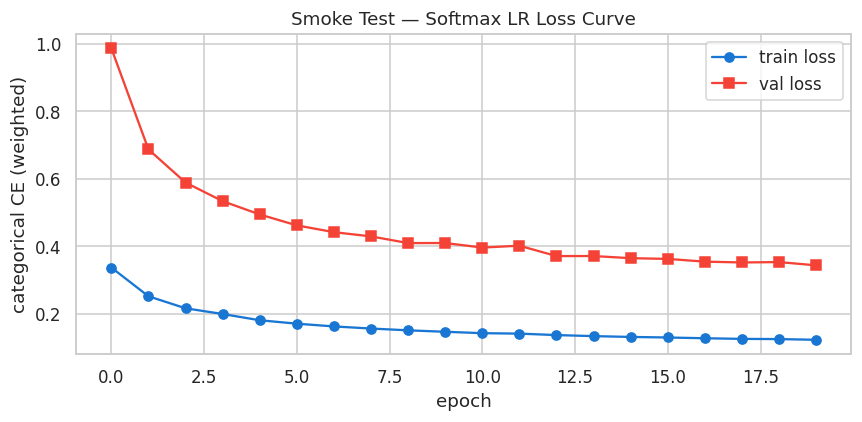

In [7]:
# quick smoke test on the tuning split
_t = time.time()
_smoke = SoftmaxRegressionScratch(n_classes=N_CLASSES, lr=0.1, lambda_=0.0,
                                  batch_size=8192, epochs=20, verbose=True)
_smoke.fit(X_tr, y_tr, X_val, y_val)
_val_macro_f1 = f1_score(y_val, _smoke.predict(X_val), average='macro')

_log('')
_log('── SECTION 4 : FROM-SCRATCH SOFTMAX LR — SMOKE TEST ───────')
_log(f'  Default hyperparams (lr=0.1, lambda=0, batch=8192, epochs=20)')
_log(f'  Validation MACRO-F1 : {_val_macro_f1:.4f}   (fit took {time.time()-_t:.1f}s)')
_log(f'  Loss went {_smoke.history["train_loss"][0]:.4f} -> '
     f'{_smoke.history["train_loss"][-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(_smoke.history['train_loss'], 'o-', label='train loss', color='#1976D2')
ax.plot(_smoke.history['val_loss'],  's-', label='val loss',   color='#F44336')
ax.set_xlabel('epoch'); ax.set_ylabel('categorical CE (weighted)')
ax.set_title('Smoke Test — Softmax LR Loss Curve')
ax.legend()
plt.tight_layout()
_savefig('03_smoke_test_loss.png', fig)
plt.show()

## 5. Hyperparameter Tuning — Grid Search (Macro-F1)
Same hyperparameter knobs as the binary notebook, but now ranked by **validation macro-F1** — the metric we actually care about for imbalanced multi-class.

| Hyperparameter | Grid |
|---|---|
| `lr` | 0.1, 0.5, 1.0 |
| `lambda_` | 0.0, 0.1, 1.0 |
| `batch_size` | 4096, 16384 |

Binary's best `lr` was 0.5 (the edge of the previous grid) — so we extend the upper bound to 1.0 here, and drop the unhelpful 0.01 from the bottom.

Tuning is done on **real-distribution training data + class weighting** (so the grid search isn't biased by SMOTE's synthetic rows). The winning config is then retrained both ways in Section 6.

In [8]:
param_grid = {
    'lr':         [0.1, 0.5, 1.0],
    'lambda_':    [0.0, 0.1, 1.0],
    'batch_size': [4096, 16384],
}
GRID_EPOCHS = 30

results, histories = [], {}

_log('')
_log('── SECTION 5 : GRID SEARCH (ranked by macro-F1) ───────────')
_log(f'  Grid: {len(param_grid["lr"])} lr x {len(param_grid["lambda_"])} lambda '
     f'x {len(param_grid["batch_size"])} batch = '
     f'{len(param_grid["lr"])*len(param_grid["lambda_"])*len(param_grid["batch_size"])} fits')

t_all = time.time()
for lr in param_grid['lr']:
    for lam in param_grid['lambda_']:
        for bs in param_grid['batch_size']:
            t0 = time.time()
            model = SoftmaxRegressionScratch(n_classes=N_CLASSES, lr=lr, lambda_=lam,
                                             batch_size=bs, epochs=GRID_EPOCHS,
                                             class_weight=True, random_state=RANDOM_SEED)
            model.fit(X_tr, y_tr, X_val, y_val)
            yv = model.predict(X_val)
            row = {
                'lr': lr, 'lambda_': lam, 'batch_size': bs,
                'val_macro_f1':    f1_score(y_val, yv, average='macro'),
                'val_weighted_f1': f1_score(y_val, yv, average='weighted'),
                'val_accuracy':    accuracy_score(y_val, yv),
                'final_loss':      model.history['train_loss'][-1],
                'fit_seconds':     time.time() - t0,
            }
            results.append(row)
            histories[(lr, lam, bs)] = model.history
            _log(f'  lr={lr:<4} lambda={lam:<4} batch={bs:<6} -> '
                 f'macroF1={row["val_macro_f1"]:.4f}  acc={row["val_accuracy"]:.4f}  '
                 f'({row["fit_seconds"]:.1f}s)')

results_df = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
_log('')
_log(f'  Total grid-search time : {time.time()-t_all:.1f}s')
_log('  Results (sorted by validation macro-F1):')
_log(results_df.to_string(index=False))
display(results_df)

best = results_df.iloc[0]
_log('')
_log(f'  BEST CONFIG: lr={best.lr}, lambda_={best.lambda_}, batch_size={int(best.batch_size)}')
_log(f'              val macro-F1={best.val_macro_f1:.4f}  val acc={best.val_accuracy:.4f}')


── SECTION 5 : GRID SEARCH (ranked by macro-F1) ───────────
  Grid: 3 lr x 3 lambda x 2 batch = 18 fits
  lr=0.1  lambda=0.0  batch=4096   -> macroF1=0.6108  acc=0.8983  (69.0s)
  lr=0.1  lambda=0.0  batch=16384  -> macroF1=0.5654  acc=0.8556  (69.1s)
  lr=0.1  lambda=0.1  batch=4096   -> macroF1=0.6102  acc=0.8978  (67.4s)
  lr=0.1  lambda=0.1  batch=16384  -> macroF1=0.5654  acc=0.8555  (66.3s)
  lr=0.1  lambda=1.0  batch=4096   -> macroF1=0.6046  acc=0.8934  (67.6s)
  lr=0.1  lambda=1.0  batch=16384  -> macroF1=0.5652  acc=0.8552  (66.6s)
  lr=0.5  lambda=0.0  batch=4096   -> macroF1=0.6289  acc=0.9126  (67.9s)
  lr=0.5  lambda=0.0  batch=16384  -> macroF1=0.6182  acc=0.9056  (66.3s)
  lr=0.5  lambda=0.1  batch=4096   -> macroF1=0.6264  acc=0.9101  (67.3s)
  lr=0.5  lambda=0.1  batch=16384  -> macroF1=0.6181  acc=0.9056  (66.1s)
  lr=0.5  lambda=1.0  batch=4096   -> macroF1=0.6087  acc=0.8937  (67.4s)
  lr=0.5  lambda=1.0  batch=16384  -> macroF1=0.6166  acc=0.9044  (66.2s)
  lr=1.

,lr,lambda_,batch_size,val_macro_f1,val_weighted_f1,val_accuracy,final_loss,fit_seconds
0,1.0000,0.0000,4096,0.6361,0.9429,0.9165,0.0899,67.2807
1,0.5000,0.0000,4096,0.6289,0.9398,0.9126,0.0842,67.9476
2,1.0000,0.0000,16384,0.6284,0.9395,0.9134,0.0844,66.1067
3,1.0000,0.1000,4096,0.6283,0.9392,0.9111,0.0941,67.2262
4,1.0000,0.1000,16384,0.6281,0.9393,0.9132,0.0846,66.5217
5,0.5000,0.1000,4096,0.6264,0.9382,0.9101,0.0861,67.2973
6,1.0000,1.0000,16384,0.6252,0.9382,0.9115,0.0867,66.3451
7,0.5000,0.0000,16384,0.6182,0.9338,0.9056,0.0939,66.3068
8,0.5000,0.1000,16384,0.6181,0.9338,0.9056,0.0940,66.1306
9,0.5000,1.0000,16384,0.6166,0.9330,0.9044,0.0954,66.2387



  BEST CONFIG: lr=1.0, lambda_=0.0, batch_size=4096
              val macro-F1=0.6361  val acc=0.9165


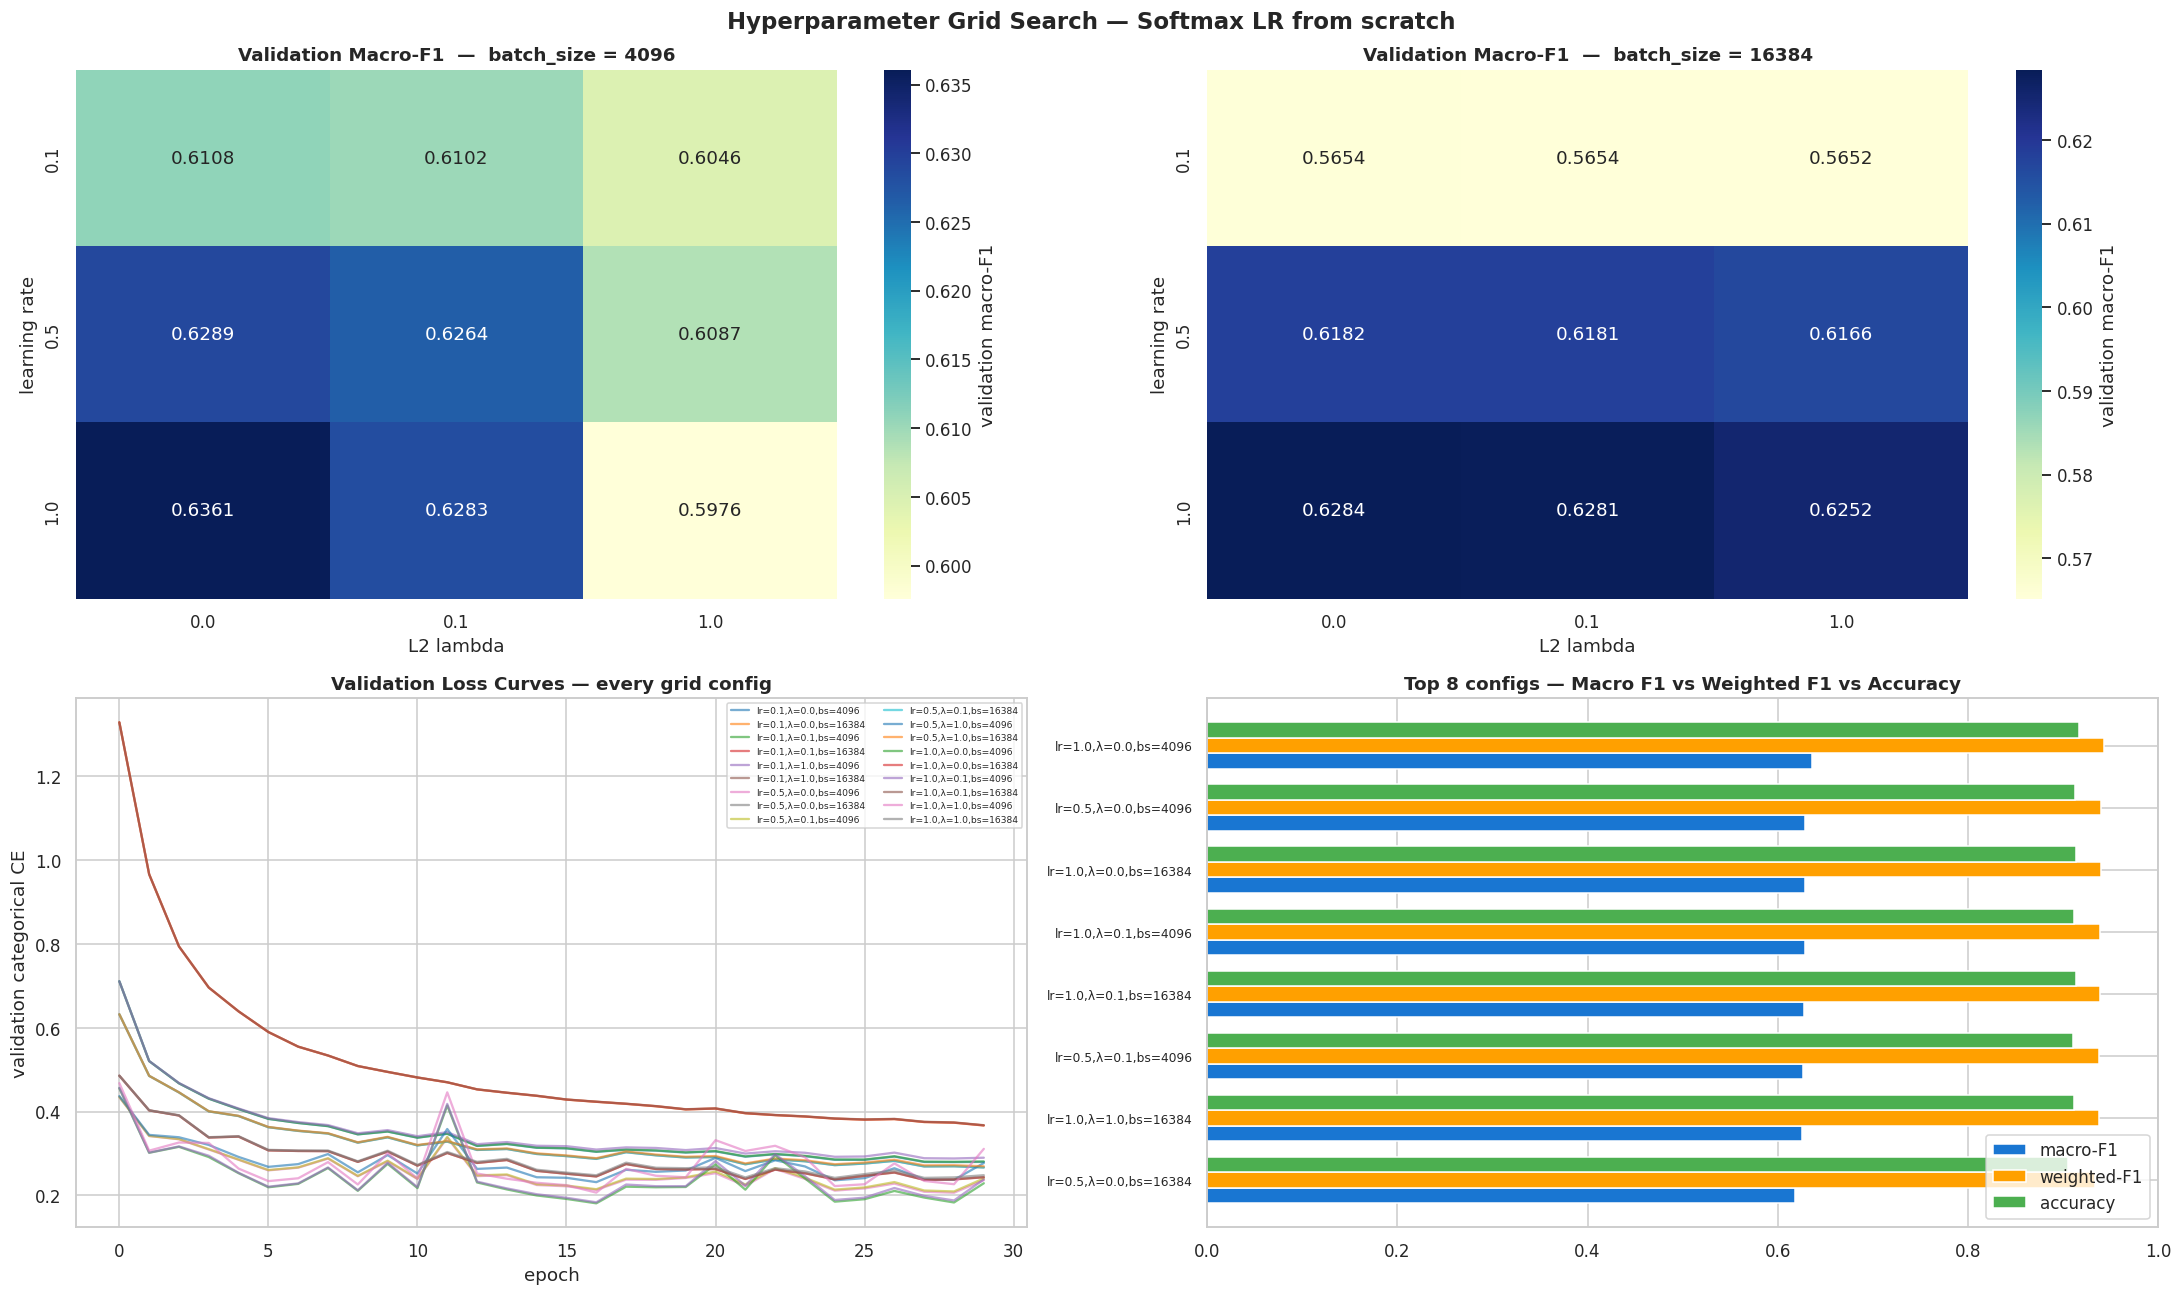

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# heatmaps: macro-F1 over lr x lambda, one per batch size
for k, bs in enumerate(param_grid['batch_size']):
    ax = axes[0, k]
    sub = results_df[results_df['batch_size'] == bs]
    pivot = sub.pivot(index='lr', columns='lambda_', values='val_macro_f1')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
                cbar_kws={'label': 'validation macro-F1'})
    ax.set_title(f'Validation Macro-F1  —  batch_size = {bs}', fontweight='bold')
    ax.set_xlabel('L2 lambda'); ax.set_ylabel('learning rate')

# all loss curves overlaid
ax = axes[1, 0]
for (lr, lam, bs), hist in histories.items():
    ax.plot(hist['val_loss'], alpha=0.6, label=f'lr={lr},λ={lam},bs={bs}')
ax.set_xlabel('epoch'); ax.set_ylabel('validation categorical CE')
ax.set_title('Validation Loss Curves — every grid config', fontweight='bold')
ax.legend(fontsize=6, ncol=2)

# top configs: macro vs weighted F1 vs accuracy
ax = axes[1, 1]
top = results_df.head(8).iloc[::-1]
ylabels = [f'lr={r.lr},λ={r.lambda_},bs={int(r.batch_size)}' for r in top.itertuples()]
yy = np.arange(len(top))
ax.barh(yy - 0.25, top['val_macro_f1'],    0.25, label='macro-F1', color='#1976D2')
ax.barh(yy,        top['val_weighted_f1'], 0.25, label='weighted-F1', color='#FFA000')
ax.barh(yy + 0.25, top['val_accuracy'],    0.25, label='accuracy', color='#4CAF50')
ax.set_yticks(yy); ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlim(0, 1)
ax.set_title('Top 8 configs — Macro F1 vs Weighted F1 vs Accuracy', fontweight='bold')
ax.legend()

plt.suptitle('Hyperparameter Grid Search — Softmax LR from scratch',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('04_grid_search.png', fig)
plt.show()

## 6. SMOTE vs Class-Weighting — Final Models
Take the best hyperparameter config from Section 5 and train it **two ways**:

| | A — Class Weighting | B — SMOTE |
|---|---|---|
| Data | real-distribution train (2.06M rows) | capped-SMOTE train (2.92M rows) |
| Imbalance | inverse-frequency loss weights | synthetic minority oversampling |
| `class_weight` | `True` | `False` |

Both evaluated **once** on the held-out real-world test set. The binary notebook found a tie at 5:1 imbalance — multi-class is ~1000:1, so the gap may be bigger here.

In [10]:
best_lr, best_lam, best_bs = float(best.lr), float(best.lambda_), int(best.batch_size)
FINAL_EPOCHS = 60

def evaluate_multi(model, X, y):
    pred = model.predict(X)
    return {
        'accuracy':    accuracy_score(y, pred),
        'macro_f1':    f1_score(y, pred, average='macro'),
        'weighted_f1': f1_score(y, pred, average='weighted'),
        'macro_prec':  precision_score(y, pred, average='macro'),
        'macro_rec':   recall_score(y, pred, average='macro'),
    }, pred

_log('')
_log('── SECTION 6 : FINAL MODELS — STRATEGY A vs B ─────────────')
_log(f'  Best config: lr={best_lr}, lambda_={best_lam}, '
     f'batch_size={best_bs}, epochs={FINAL_EPOCHS}')

# A : real data + class weighting
_log('')
_log('  [A] Class weighting — training on real-distribution data ...')
t0 = time.time()
model_A = SoftmaxRegressionScratch(n_classes=N_CLASSES, lr=best_lr, lambda_=best_lam,
                                   batch_size=best_bs, epochs=FINAL_EPOCHS,
                                   class_weight=True, random_state=RANDOM_SEED)
model_A.fit(X_train_full, y_train_full, X_test, y_test)
metrics_A, pred_A = evaluate_multi(model_A, X_test, y_test)
_log(f'      done in {time.time()-t0:.1f}s')

# B : SMOTE data, no class weighting
_log('  [B] SMOTE — training on capped synthetic-balanced data ...')
t0 = time.time()
model_B = SoftmaxRegressionScratch(n_classes=N_CLASSES, lr=best_lr, lambda_=best_lam,
                                   batch_size=best_bs, epochs=FINAL_EPOCHS,
                                   class_weight=False, random_state=RANDOM_SEED)
model_B.fit(X_smote, y_smote, X_test, y_test)
metrics_B, pred_B = evaluate_multi(model_B, X_test, y_test)
_log(f'      done in {time.time()-t0:.1f}s')

# comparison table
cmp_df = pd.DataFrame({'A_class_weight': metrics_A, 'B_smote': metrics_B})
cmp_df['difference'] = cmp_df['B_smote'] - cmp_df['A_class_weight']
cmp_df['winner'] = np.where(cmp_df['difference'].abs() < 1e-4, 'tie',
                            np.where(cmp_df['difference'] > 0, 'B_smote', 'A_class_weight'))

_log('')
_log('  TEST-SET COMPARISON (real-world distribution):')
_log(cmp_df.to_string())
display(cmp_df)

f1_A = metrics_A['macro_f1']
f1_B = metrics_B['macro_f1']
overall = 'B (SMOTE)' if f1_B > f1_A else 'A (class weighting)'
_log('')
_log(f'  Overall winner by MACRO-F1 : {overall}')
_log(f'    A class-weight macro-F1 = {f1_A:.4f}  |  B SMOTE macro-F1 = {f1_B:.4f}')
print(f'\nWinner by macro-F1: {overall}')


── SECTION 6 : FINAL MODELS — STRATEGY A vs B ─────────────
  Best config: lr=1.0, lambda_=0.0, batch_size=4096, epochs=60

  [A] Class weighting — training on real-distribution data ...
      done in 236.9s
  [B] SMOTE — training on capped synthetic-balanced data ...
      done in 327.9s

  TEST-SET COMPARISON (real-world distribution):
             A_class_weight  B_smote  difference          winner
accuracy             0.9224   0.9704      0.0479         B_smote
macro_f1             0.6582   0.7527      0.0944         B_smote
weighted_f1          0.9479   0.9798      0.0319         B_smote
macro_prec           0.6167   0.7142      0.0975         B_smote
macro_rec            0.9781   0.9771     -0.0010  A_class_weight


,A_class_weight,B_smote,difference,winner
accuracy,0.9224,0.9704,0.0479,B_smote
macro_f1,0.6582,0.7527,0.0944,B_smote
weighted_f1,0.9479,0.9798,0.0319,B_smote
macro_prec,0.6167,0.7142,0.0975,B_smote
macro_rec,0.9781,0.9771,-0.0010,A_class_weight



  Overall winner by MACRO-F1 : B (SMOTE)
    A class-weight macro-F1 = 0.6582  |  B SMOTE macro-F1 = 0.7527

Winner by macro-F1: B (SMOTE)


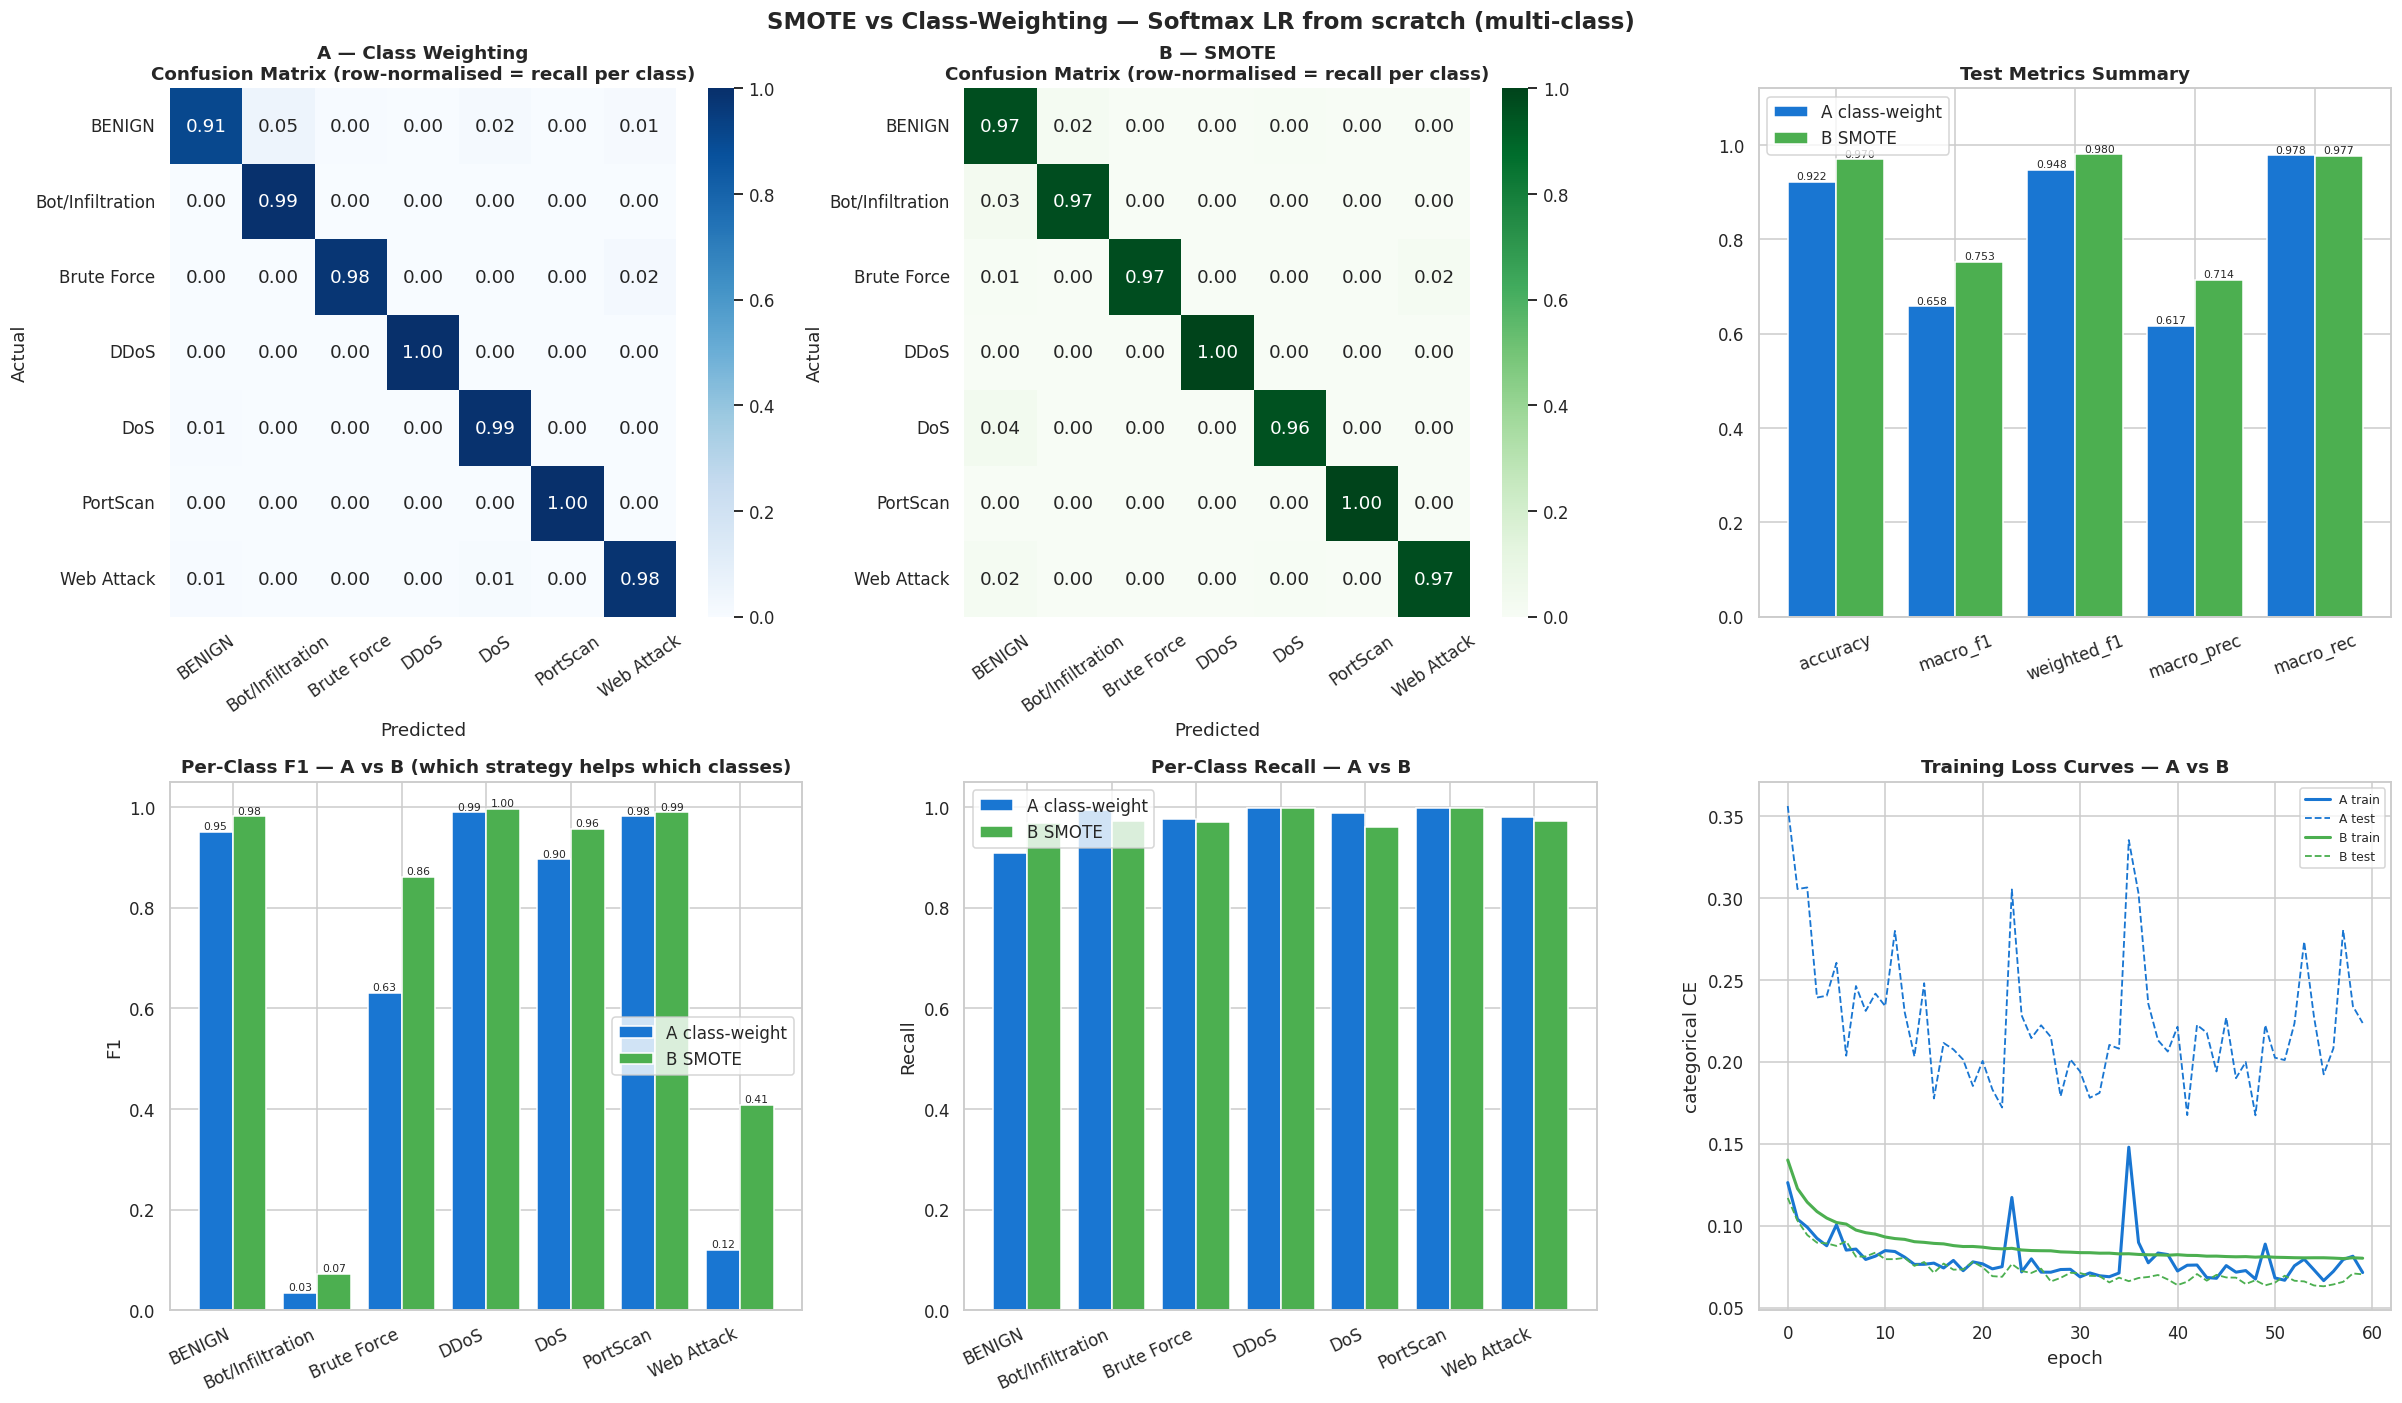

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# confusion matrix A (normalised by row = recall per class)
cm_A      = confusion_matrix(y_test, pred_A)
cm_A_norm = cm_A.astype(float) / cm_A.sum(axis=1, keepdims=True)
sns.heatmap(cm_A_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[0, 0].set_title('A — Class Weighting\nConfusion Matrix (row-normalised = recall per class)',
                     fontweight='bold')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')
axes[0, 0].tick_params(axis='x', rotation=35)

# confusion matrix B
cm_B      = confusion_matrix(y_test, pred_B)
cm_B_norm = cm_B.astype(float) / cm_B.sum(axis=1, keepdims=True)
sns.heatmap(cm_B_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[0, 1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[0, 1].set_title('B — SMOTE\nConfusion Matrix (row-normalised = recall per class)',
                     fontweight='bold')
axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')
axes[0, 1].tick_params(axis='x', rotation=35)

# overall metric bars
ax = axes[0, 2]
metric_names = ['accuracy', 'macro_f1', 'weighted_f1', 'macro_prec', 'macro_rec']
xx = np.arange(len(metric_names))
ax.bar(xx - 0.2, [metrics_A[m] for m in metric_names], 0.4,
       label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, [metrics_B[m] for m in metric_names], 0.4,
       label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(metric_names, rotation=20)
ax.set_ylim(0, 1.12)
ax.set_title('Test Metrics Summary', fontweight='bold')
ax.legend()
for i, m in enumerate(metric_names):
    ax.text(i - 0.2, metrics_A[m], f'{metrics_A[m]:.3f}', ha='center', va='bottom', fontsize=7)
    ax.text(i + 0.2, metrics_B[m], f'{metrics_B[m]:.3f}', ha='center', va='bottom', fontsize=7)

# per-class F1 — grouped bar, this is the headline view for imbalanced multi-class
ax = axes[1, 0]
f1_per_class_A = f1_score(y_test, pred_A, average=None)
f1_per_class_B = f1_score(y_test, pred_B, average=None)
xx = np.arange(N_CLASSES)
ax.bar(xx - 0.2, f1_per_class_A, 0.4, label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, f1_per_class_B, 0.4, label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('F1'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 — A vs B (which strategy helps which classes)', fontweight='bold')
ax.legend()
for i, (a, b) in enumerate(zip(f1_per_class_A, f1_per_class_B)):
    ax.text(i - 0.2, a, f'{a:.2f}', ha='center', va='bottom', fontsize=7)
    ax.text(i + 0.2, b, f'{b:.2f}', ha='center', va='bottom', fontsize=7)

# per-class recall — often where SMOTE shows the most impact on minorities
ax = axes[1, 1]
rec_A = recall_score(y_test, pred_A, average=None)
rec_B = recall_score(y_test, pred_B, average=None)
ax.bar(xx - 0.2, rec_A, 0.4, label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, rec_B, 0.4, label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class Recall — A vs B', fontweight='bold')
ax.legend()

# loss curves
ax = axes[1, 2]
ax.plot(model_A.history['train_loss'], color='#1976D2', lw=2, label='A train')
ax.plot(model_A.history['val_loss'],   color='#1976D2', lw=1.2, ls='--', label='A test')
ax.plot(model_B.history['train_loss'], color='#4CAF50', lw=2, label='B train')
ax.plot(model_B.history['val_loss'],   color='#4CAF50', lw=1.2, ls='--', label='B test')
ax.set_xlabel('epoch'); ax.set_ylabel('categorical CE')
ax.set_title('Training Loss Curves — A vs B', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('SMOTE vs Class-Weighting — Softmax LR from scratch (multi-class)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('05_smote_vs_classweight.png', fig)
plt.show()

## 7. Detailed Per-Class Evaluation — Winning Model
The full classification report (precision / recall / F1 / support per class) for the strategy that won, plus a final raw-count confusion matrix.


── SECTION 7 : WINNING MODEL — PER-CLASS EVALUATION ───────
  Winning strategy : B_smote  (macro-F1 = 0.7527)

                  precision    recall  f1-score   support

          BENIGN     0.9965    0.9685    0.9823    429677
Bot/Infiltration     0.0378    0.9724    0.0727       398
     Brute Force     0.7743    0.9710    0.8616      1830
            DDoS     0.9949    0.9983    0.9966     25603
             DoS     0.9544    0.9599    0.9571     38752
        PortScan     0.9826    0.9974    0.9900     18164
      Web Attack     0.2585    0.9720    0.4084       429

        accuracy                         0.9704    514853
       macro avg     0.7142    0.9771    0.7527    514853
    weighted avg     0.9906    0.9704    0.9798    514853

                  precision    recall  f1-score   support

          BENIGN     0.9965    0.9685    0.9823    429677
Bot/Infiltration     0.0378    0.9724    0.0727       398
     Brute Force     0.7743    0.9710    0.8616      1830
            DD

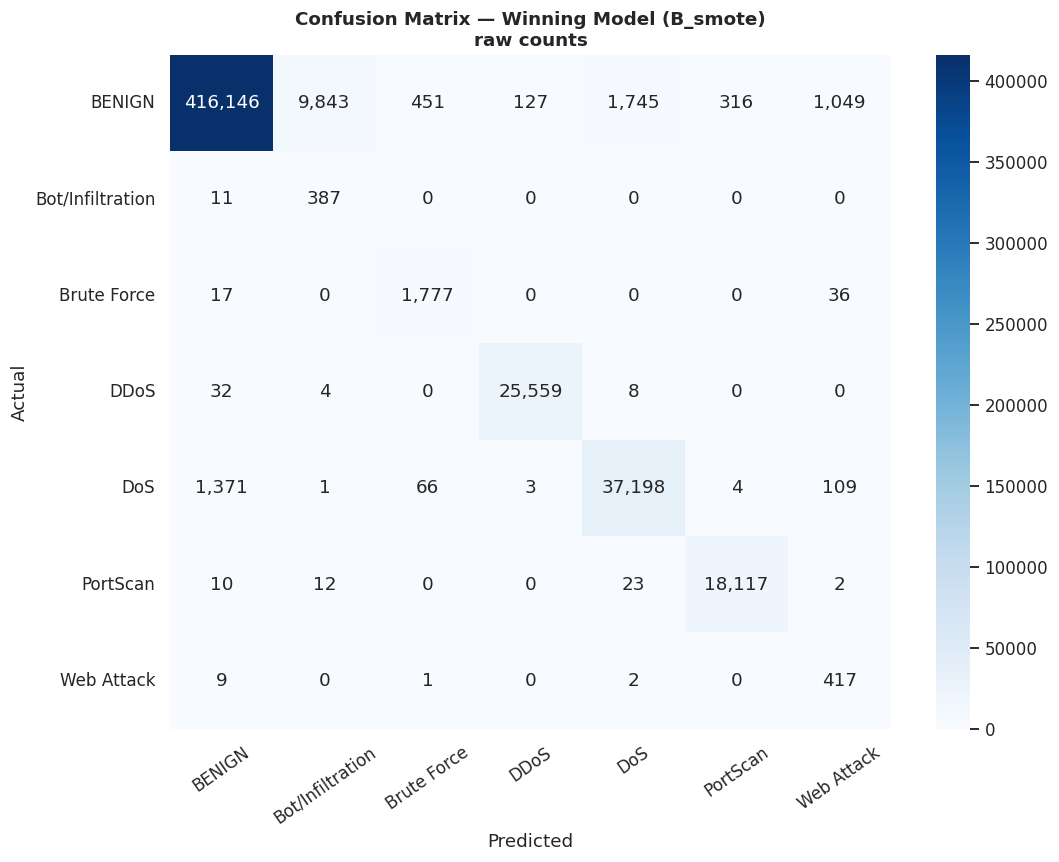

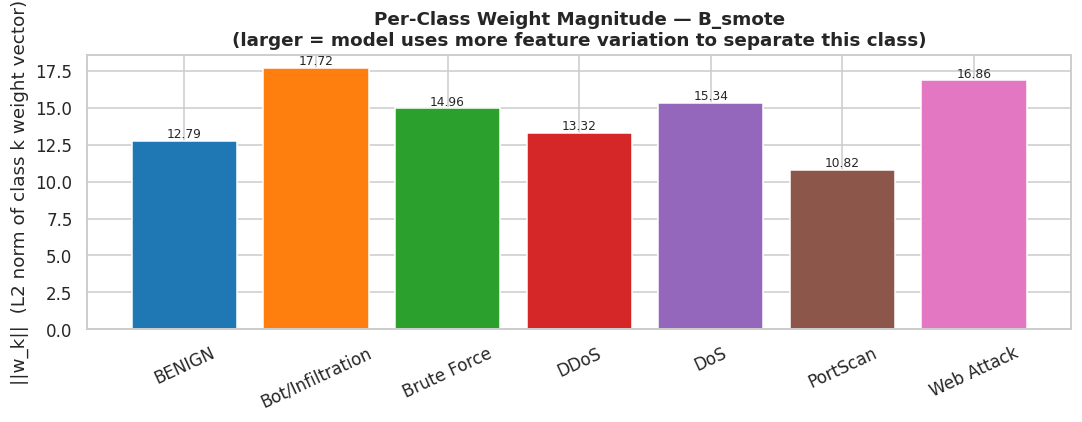

In [12]:
# pick the winning model by macro-F1
if metrics_B['macro_f1'] > metrics_A['macro_f1']:
    final_model, final_metrics, final_strategy = model_B, metrics_B, 'B_smote'
    final_pred = pred_B
else:
    final_model, final_metrics, final_strategy = model_A, metrics_A, 'A_class_weight'
    final_pred = pred_A

_log('')
_log('── SECTION 7 : WINNING MODEL — PER-CLASS EVALUATION ───────')
_log(f'  Winning strategy : {final_strategy}  (macro-F1 = {final_metrics["macro_f1"]:.4f})')
_log('')
report = classification_report(y_test, final_pred, target_names=CLASS_NAMES, digits=4)
_log(report)
print(report)

# raw-count confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — Winning Model ({final_strategy})\nraw counts',
             fontweight='bold')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
_savefig('06_final_confusion_matrix.png', fig)
plt.show()

# weight magnitude per class — softmax has K weight vectors
weight_norms = np.linalg.norm(final_model.W, axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(CLASS_NAMES, weight_norms, color=sns.color_palette('tab10', N_CLASSES))
ax.set_ylabel('||w_k||  (L2 norm of class k weight vector)')
ax.set_title(f'Per-Class Weight Magnitude — {final_strategy}\n'
             '(larger = model uses more feature variation to separate this class)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(weight_norms):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
_savefig('07_weight_norms_per_class.png', fig)
plt.show()

## 8. Save Models, Metrics & Report

In [13]:
# save BOTH trained models (numpy weight matrices + bias + config)
p1 = os.path.join(OUT_DIR, 'softmax_scratch_multi_A_classweight.npz')
np.savez(p1, W=model_A.W, b=model_A.b,
         features=np.array(selected_features), classes=np.array(CLASS_NAMES),
         lr=best_lr, lambda_=best_lam, batch_size=best_bs, epochs=FINAL_EPOCHS,
         strategy='A_class_weight')

p2 = os.path.join(OUT_DIR, 'softmax_scratch_multi_B_smote.npz')
np.savez(p2, W=model_B.W, b=model_B.b,
         features=np.array(selected_features), classes=np.array(CLASS_NAMES),
         lr=best_lr, lambda_=best_lam, batch_size=best_bs, epochs=FINAL_EPOCHS,
         strategy='B_smote')

p3 = os.path.join(OUT_DIR, 'gridsearch_results_multi.csv')
results_df.to_csv(p3, index=False)

p4 = os.path.join(OUT_DIR, 'smote_vs_classweight_comparison_multi.csv')
cmp_df.to_csv(p4)

p5 = os.path.join(OUT_DIR, 'final_metrics_multi.json')
with open(p5, 'w') as f:
    json.dump({
        'model': 'SoftmaxRegressionScratch',
        'task': 'multi-class (7 attack families)',
        'class_names': CLASS_NAMES,
        'best_hyperparameters': {'lr': best_lr, 'lambda_': best_lam,
                                 'batch_size': best_bs, 'epochs': FINAL_EPOCHS},
        'strategy_A_class_weight': metrics_A,
        'strategy_B_smote':        metrics_B,
        'winning_strategy':        final_strategy,
        'winning_metrics':         final_metrics,
    }, f, indent=2)

_log('')
_log('── SECTION 8 : FILES SAVED ────────────────────────────────')
for p in [p1, p2, p3, p4, p5]:
    _log(f'  {os.path.basename(p)}')
    print(f'  {os.path.basename(p)}')


── SECTION 8 : FILES SAVED ────────────────────────────────
  softmax_scratch_multi_A_classweight.npz
  softmax_scratch_multi_A_classweight.npz
  softmax_scratch_multi_B_smote.npz
  softmax_scratch_multi_B_smote.npz
  gridsearch_results_multi.csv
  gridsearch_results_multi.csv
  smote_vs_classweight_comparison_multi.csv
  smote_vs_classweight_comparison_multi.csv
  final_metrics_multi.json
  final_metrics_multi.json


In [14]:
_log('')
_log('=' * 70)
_log('SUMMARY  --  MULTI-CLASS MODELLING (Softmax Regression from scratch)')
_log('=' * 70)
_log(f'  Classes         : {N_CLASSES}   ({CLASS_NAMES})')
_log(f'  Features used   : {len(selected_features)}')
_log(f'  Test rows       : {X_test.shape[0]:,}  (real-world distribution)')
_log('')
_log('  Best hyperparameters (grid search on validation macro-F1):')
_log(f'    learning rate : {best_lr}')
_log(f'    L2 lambda     : {best_lam}')
_log(f'    batch size    : {best_bs}')
_log('')
_log('  IMBALANCE STRATEGY COMPARISON (test set):')
_log(f'    {"metric":<14} {"A class-weight":>16} {"B SMOTE":>16}')
for m in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_prec', 'macro_rec']:
    _log(f'    {m:<14} {metrics_A[m]:>16.4f} {metrics_B[m]:>16.4f}')
_log('')
_log(f'  WINNING STRATEGY : {final_strategy}  (by macro-F1)')
_log(f'  Final macro-F1   : {final_metrics["macro_f1"]:.4f}')
_log(f'  Final accuracy   : {final_metrics["accuracy"]:.4f}')
_log('')
_log('  Comparison with binary task:')
_log('    binary  : F1 = 0.9052 (class-weight) vs 0.9051 (SMOTE)  -> tie')
_log(f'    multi   : macroF1 = {metrics_A["macro_f1"]:.4f} (class-weight) '
     f'vs {metrics_B["macro_f1"]:.4f} (SMOTE)  -> {final_strategy} wins')

FIGURE_INDEX = [
    ('01_data_journey_multiclass.png',   'Pipeline rows & features at every stage'),
    ('02_class_balance.png',             'Real-train vs SMOTE-train + test class distributions'),
    ('03_smoke_test_loss.png',           'Smoke test loss curve'),
    ('04_grid_search.png',               'Grid search heatmaps + loss curves + top configs'),
    ('05_smote_vs_classweight.png',      'SMOTE vs class-weighting -- full side-by-side'),
    ('06_final_confusion_matrix.png',    'Winning model raw-count confusion matrix'),
    ('07_weight_norms_per_class.png',    'Per-class weight magnitude of winning model'),
]
_log('')
_log('  Figures:')
for fname, desc in FIGURE_INDEX:
    _log(f'    {fname:<36} {desc}')

write_report()

print('\n' + '=' * 55)
print('MULTI-CLASS MODELLING COMPLETE -- Softmax LR (scratch)')
print('=' * 55)
print(f'  A (class-weight) macro-F1 : {metrics_A["macro_f1"]:.4f}')
print(f'  B (SMOTE)        macro-F1 : {metrics_B["macro_f1"]:.4f}')
print(f'  Winner : {final_strategy}')
print(f'  Report  -> {OUT_DIR}/Modeling_Multiclass_Report.txt')
print(f'  Figures -> {FIGURES_DIR}/  ({len(FIGURE_INDEX)} figures)')


SUMMARY  --  MULTI-CLASS MODELLING (Softmax Regression from scratch)
  Classes         : 7   (['BENIGN', 'Bot/Infiltration', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack'])
  Features used   : 47
  Test rows       : 514,853  (real-world distribution)

  Best hyperparameters (grid search on validation macro-F1):
    learning rate : 1.0
    L2 lambda     : 0.0
    batch size    : 4096

  IMBALANCE STRATEGY COMPARISON (test set):
    metric           A class-weight          B SMOTE
    accuracy                 0.9224           0.9704
    macro_f1                 0.6582           0.7527
    weighted_f1              0.9479           0.9798
    macro_prec               0.6167           0.7142
    macro_rec                0.9781           0.9771

  WINNING STRATEGY : B_smote  (by macro-F1)
  Final macro-F1   : 0.7527
  Final accuracy   : 0.9704

  Comparison with binary task:
    binary  : F1 = 0.9052 (class-weight) vs 0.9051 (SMOTE)  -> tie
    multi   : macroF1 = 0.6582 (class-wei